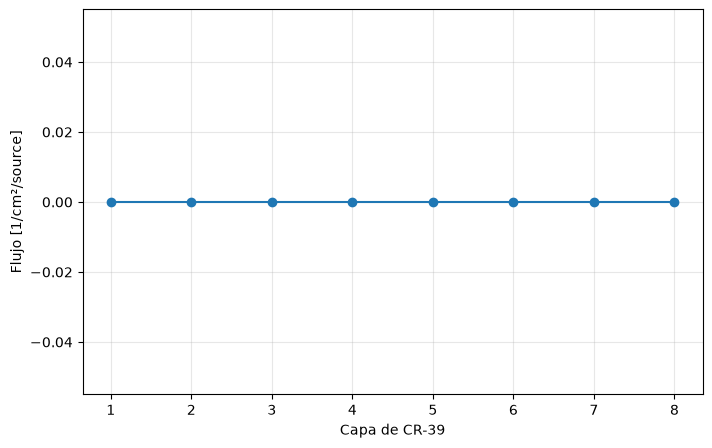

In [1]:
import numpy as np
import matplotlib.pyplot as plt

archivo = "../out/flujo_CR39_reg.out"

capas = []
regiones = []
flujo = []
error_relativo = []

leyendo = False

with open(archivo, "r", encoding="utf-8", errors="ignore") as f:
    for linea in f:

        if "#  num" in linea and "reg" in linea and "proton" in linea:
            leyendo = True
            continue

        if leyendo:
            if linea.startswith("#"):
                if capas:
                    break
                continue

            partes = linea.split()

            if len(partes) == 5:
                try:
                    capas.append(int(partes[0]))
                    regiones.append(int(partes[1]))
                    flujo.append(float(partes[3]))
                    error_relativo.append(float(partes[4]))

                except ValueError:
                    pass

capas = np.array(capas)
regiones = np.array(regiones)
flujo = np.array(flujo)
error_relativo = np.array(error_relativo)

error = flujo * error_relativo

plt.figure(figsize=(8,5))

plt.errorbar(
    capas,
    flujo,
    yerr=error,
    marker="o",
    capsize=3
)

plt.xlabel("Capa de CR-39")
plt.ylabel("Flujo [1/cm²/source]")
plt.xticks(capas)
plt.grid(alpha=0.3)

plt.show()